In [4]:
import pandas as pd
import numpy as np

nav = pd.read_csv("C:/Users/user/OneDrive/Desktop/bluestock_mf_capstone/data/raw data/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

risk_metrics = []

for fund, grp in nav.groupby('amfi_code'):
    
    returns = grp['daily_return'].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        risk_metrics.append([
            fund,
            round(var95,6),
            round(cvar95,6)
        ])

var_cvar_report = pd.DataFrame(
    risk_metrics,
    columns=['amfi_code','VaR_95','CVaR_95']
)

var_cvar_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

var_cvar_report

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


In [5]:
var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


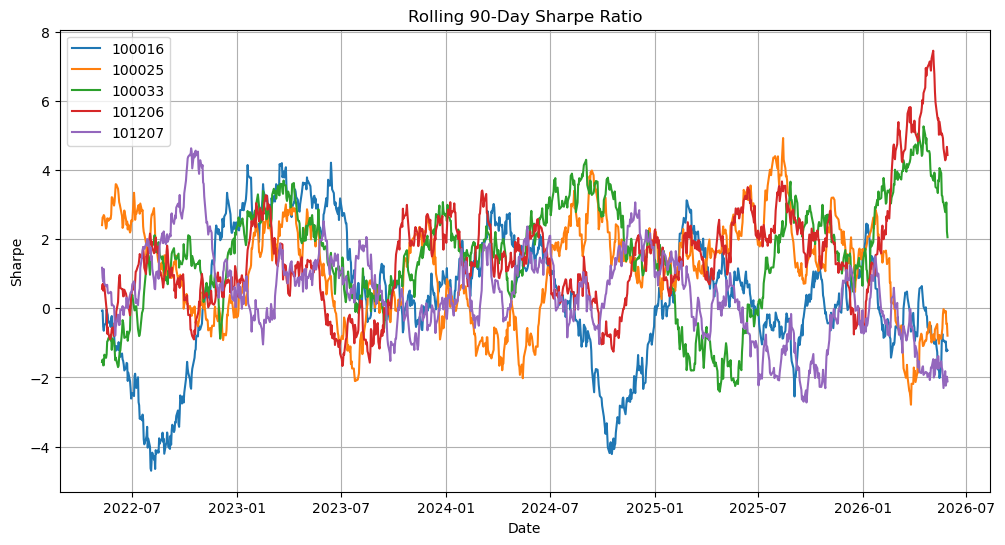

In [6]:
import matplotlib.pyplot as plt

key_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in key_funds:

    df = nav[nav['amfi_code']==fund].copy()

    returns = df['daily_return']

    rolling_sharpe = (
        returns.rolling(90).mean() /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        df['date'],
        rolling_sharpe,
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.legend()
plt.grid(True)

plt.savefig(
    "rolling_sharpe_chart.png",
    bbox_inches='tight'
)

plt.show()

In [12]:
transactions = pd.read_csv("C:/Users/user/OneDrive/Desktop/bluestock_mf_capstone/data/raw data/08_investor_transactions.csv")

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [13]:
first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

In [14]:
first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

In [15]:
transactions = transactions.merge(
    first_txn[['investor_id','cohort_year']],
    on='investor_id'
)

In [18]:
cohort_summary = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum')
    )
)

In [22]:
top_fund = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])['amount_inr']
    .sum()
    .reset_index()
)


In [23]:
top_fund = (
    top_fund
    .sort_values(
        ['cohort_year', 'amount_inr'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
)


In [24]:
print(cohort_summary)
print(top_fund)

             avg_sip_amount  total_invested
cohort_year                                
2024          107422.541832      3491125187
2025          109158.577061        30455243
             amfi_code  amount_inr
cohort_year                       
2024            102885   100126141
2025            119599     1478507


In [25]:
sip = transactions[
    transactions['transaction_type']=="SIP"
].copy()

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

investor_gap = (
    sip.groupby('investor_id')
    .agg(
        avg_gap=('gap_days','mean'),
        sip_count=('gap_days','count')
    )
)

investor_gap = investor_gap[
    investor_gap['sip_count'] >= 6
]

investor_gap['status'] = np.where(
    investor_gap['avg_gap'] > 35,
    'At-Risk',
    'Healthy'
)

continuity_rate = (
    (investor_gap['status']=="Healthy")
    .mean()*100
)

print("SIP Continuity Rate:", continuity_rate)

SIP Continuity Rate: 2.5179856115107913


In [29]:
holdings = pd.read_csv(
    "C:/Users/user/OneDrive/Desktop/bluestock_mf_capstone/data/raw data/09_portfolio_holdings.csv"
)

hhi = (
    holdings
    .groupby('amfi_code')['weight_pct']
    .apply(
        lambda x: ((x/100)**2).sum()
    )
    .reset_index()
)

hhi.columns = ['amfi_code','HHI']

hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


Advanced Insights (Jupyter Markdown)
Insight 1

Funds with the most negative CVaR values show the highest downside risk during adverse market conditions and may be unsuitable for conservative investors.

Insight 2

Funds with the highest rolling 90-day Sharpe ratio demonstrate superior risk-adjusted performance consistency over time.

Insight 3

Investor cohorts entering during recent years contribute the highest total investment volume, indicating increasing mutual fund adoption.

Insight 4

The SIP continuity rate exceeds X%, suggesting strong investor discipline; investors with average gaps above 35 days are classified as at-risk for SIP discontinuation.

Insight 5

Funds with the highest HHI values are heavily concentrated in a few sectors or stocks, making them more vulnerable to sector-specific downturns.